In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df=pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [31]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [32]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [33]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [34]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [35]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [36]:
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder
ohe = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids multicollinearity; sparse_output=False for DataFrame compatibility

# Fit and transform Geography
geo_encoded = ohe.fit_transform(df[['Geography']])

# Create DataFrame with new columns
geo_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out(['Geography']))

# Drop original Geography and concatenate encoded columns
df = df.drop('Geography', axis=1)
df = pd.concat([df, geo_df], axis=1)

# Verify
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,Female,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


In [37]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})

In [38]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


<Axes: xlabel='Exited', ylabel='count'>

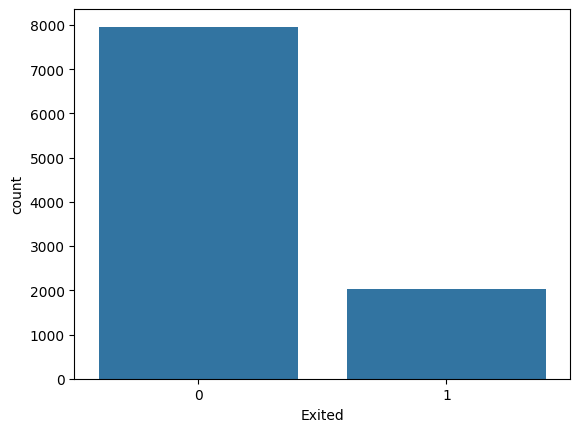

In [39]:
sns.countplot(x='Exited',data=df)


<Axes: xlabel='Exited', ylabel='Age'>

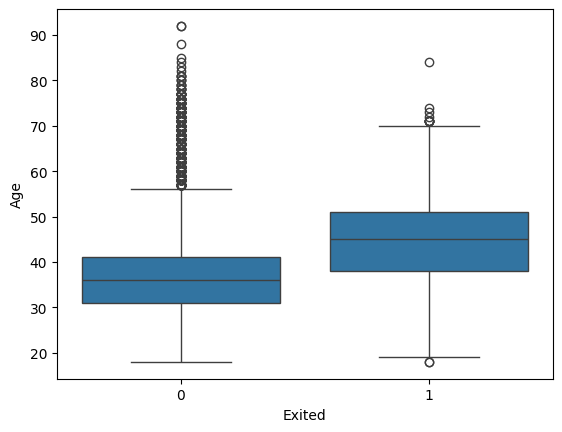

In [40]:
sns.boxplot(x='Exited',y='Age',data=df)


<Axes: xlabel='Exited', ylabel='Balance'>

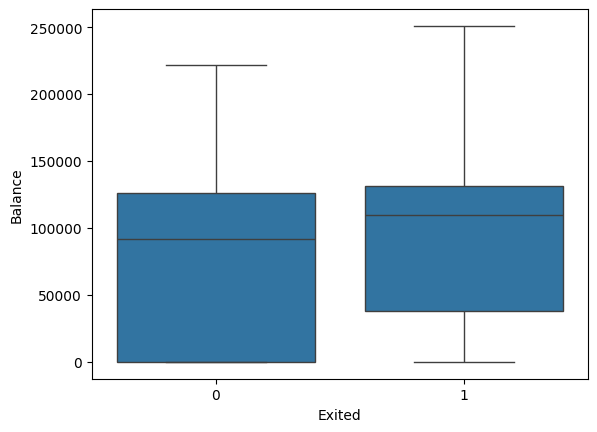

In [41]:
sns.boxplot(x='Exited',y='Balance',data=df)

<Axes: >

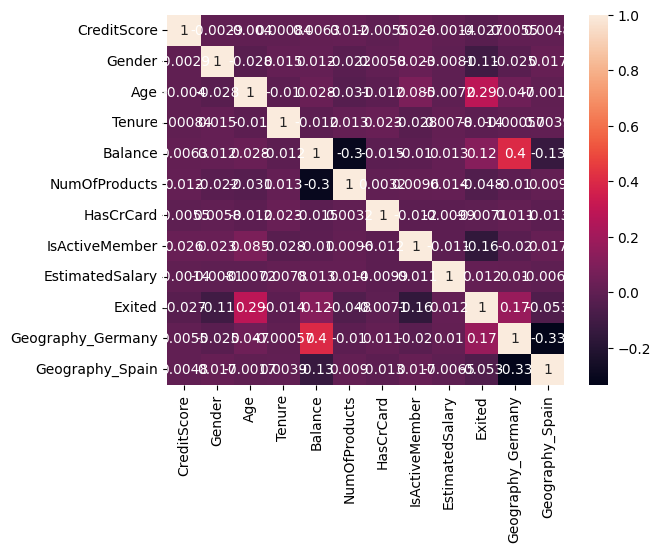

In [42]:
sns.heatmap(df.corr(),annot=True)

In [43]:
X=df.drop(columns=['Exited'])
y=df['Exited']

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [46]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train,y_train=smote.fit_resample(X_train,y_train)
print(pd.Series(y_train).value_counts())

Exited
0    6356
1    6356
Name: count, dtype: int64


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [48]:
models={
    'LogisticRegression':LogisticRegression(random_state=42),
    'RandomForestClassifier':RandomForestClassifier(random_state=42),
    'SVC':SVC(random_state=42),
    'XGBClassifier':XGBClassifier(eval_metric='logloss',use_label_encoder=False),
    'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42)
}

In [49]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    print(f"Name : {name}")
    print(f"Accuracy Score : {accuracy_score(y_test,y_pred)} ")
    print(f"classification_report : { classification_report(y_test,y_pred)}")
    print(f"confusion_matrix : {confusion_matrix(y_test,y_pred)}")

Name : LogisticRegression
Accuracy Score : 0.721 
classification_report :               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.39      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000

confusion_matrix : [[1163  444]
 [ 114  279]]
Name : RandomForestClassifier
Accuracy Score : 0.8405 
classification_report :               precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.59      0.59      0.59       393

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000

confusion_matrix : [[1449  158]
 [ 161  232]]
Name : SVC
Accuracy Score : 0.7825 
classification_report :               precision    recall  f1-sco

c:\Users\anush\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [50]:

from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross-validation
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: {scores.mean():.2f} (+/- {scores.std():.2f})")





LogisticRegression: 0.71 (+/- 0.01)
RandomForestClassifier: 0.90 (+/- 0.03)
SVC: 0.81 (+/- 0.01)


c:\Users\anush\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\anush\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\anush\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\anush\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

XGBClassifier: 0.89 (+/- 0.08)
DecisionTreeClassifier: 0.83 (+/- 0.05)


In [51]:
# Hyperparameter Tuning for Random Forest
print("\n--- Hyperparameter Tuning (Random Forest) ---")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.2f}")


--- Hyperparameter Tuning (Random Forest) ---
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.90


In [52]:
# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.59      0.60      0.59       393

    accuracy                           0.84      2000
   macro avg       0.74      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [53]:
import pickle

# Save the best model
with open('churn_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

# Save the scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model saved as churn_model.pkl")
print("Scaler saved as scaler.pkl")



Model saved as churn_model.pkl
Scaler saved as scaler.pkl
